# Group 6 - Data Analytics Project Activity: From Raw Data to Interactive Dashboard

# Angelo, Steps 1-2

🎯 **Objective**

In this activity, you will take a real-world dataset, clean and prepare it (data wrangling), perform exploratory data analysis (EDA), and finally build an interactive dashboard using Python. This mirrors a real job workflow used by Data Analysts and Business Intelligence professionals.

## 🧩 Step 1: Dataset Selection (Real-World Data)

For this project, we have decided to use a Retail Sales Dataset from Kaggle. Here is the link to the source:

https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

In [1]:
import kagglehub

# Download latest version of kaggle dataset
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'retail-sales-dataset' dataset.
Path to dataset files: /kaggle/input/retail-sales-dataset


To check the requirements, in the code block below we can confirm that we have met every requirements:
*   ✅ At least 100+ rows - 1000 entries
*   ✅ At least 4 columns - 9 columns
*   ✅ A time-based column (date/month/year) preferred - Date column

In [2]:
import pandas as pd

# load kaggle path to pandas dataframe
df_main = pd.read_csv(path + '/retail_sales_dataset.csv')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## 🧹 Step 2: Data Wrangling (Cleaning & Preparation)

1. Load Dataset

In [3]:
# We have loaded the dataset from step #1 and here is the preview
df_main

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


2. Handle Missing Value

In [4]:
# If we look at all the sum of null or missing values, we can say that we do not have any missing values
df_main.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


3. Fix Data Types

In [5]:
# To take a peek of the current data types
df_main.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [6]:
# Here we want to change Date from 'object' to 'datetime'
df_main['Date'] = pd.to_datetime(df_main['Date'])
# Now if we look back at the types, it is now changed to 'datetime'
df_main.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


4. Remove Duplicates (if any)

In [7]:
# If we check if there are any duplicates in our dataframe, we have 0 duplicates
df_main.duplicated().sum()

np.int64(0)

5. Create new columns (feature engineering). Here we will try 2 things:
* Give new columns for the Date's Year and Month
* Binning the Age to different Age Groups

In [8]:
# Here is how we create new columns named 'Year' and 'Month' based on the 'Date' column
df_main['Year'] = df_main['Date'].dt.year
df_main['Month'] = df_main['Date'].dt.month

# if we look at the data types again, we can see two new columns
df_main.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64
Year,int32


In [9]:
# Also to peek at the first 5 rows and see Year and Month are correctly supplied
df_main.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5


In [10]:
# For the 2nd objective, we will create bins for the age group based on decades (e.g. 0-9, 10-19, 20-29, etc.)
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 969]
age_labels = ['00s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90+']
df_main['Age Group'] = pd.cut(df_main['Age'], bins=age_bins, labels=age_labels, right=False)

# let us see the new bin column
df_main.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,30s
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,20s
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,50s
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,30s
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,30s
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,2023,4,40s
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,2023,3,40s
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,2023,2,30s
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,2023,12,60s
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,2023,10,50s


In [11]:
# we can furthur confirm our binning with the following code, we can see the min and max values for each age group
df_main.groupby('Age Group')['Age'].agg(['min', 'max']).reset_index()

/tmp/ipykernel_5345/1878145145.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_main.groupby('Age Group')['Age'].agg(['min', 'max']).reset_index()


,Age Group,min,max
0,00s,NaN,NaN
1,10s,18.0,19.0
2,20s,20.0,29.0
3,30s,30.0,39.0
4,40s,40.0,49.0
5,50s,50.0,59.0
6,60s,60.0,64.0
7,70s,NaN,NaN
8,80s,NaN,NaN
9,90+,NaN,NaN


# Angelo & Ritul, Step 3

## 📊 Step 3: Exploratory Data Analysis (EDA)

1. Basic Statistics

In [12]:
# Step 3: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# to see basic statistics of each column
df_main.describe(include='all')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Age Group
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN,NaN,NaN,40s
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN,NaN,NaN,222
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000,2023.002000,6.549000,NaN
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000,2023.000000,1.000000,NaN
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000,2023.000000,4.000000,NaN
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000,2023.000000,6.000000,NaN
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000,2023.000000,10.000000,NaN
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000,2024.000000,12.000000,NaN


In [13]:
# Specific Statistics
print("Mean Sales:", df_main['Total Amount'].mean())
print("Median Sales:", df_main['Total Amount'].median())
print("Maximum Sale:", df_main['Total Amount'].max())
print("Minimum Sale:", df_main['Total Amount'].min())

Mean Sales: 456.0
Median Sales: 135.0
Maximum Sale: 2000
Minimum Sale: 25


2. Group Analysis adjusted based on dataset:
* Sales by Product Category
* Profit by Age Group
* Monthly Trends

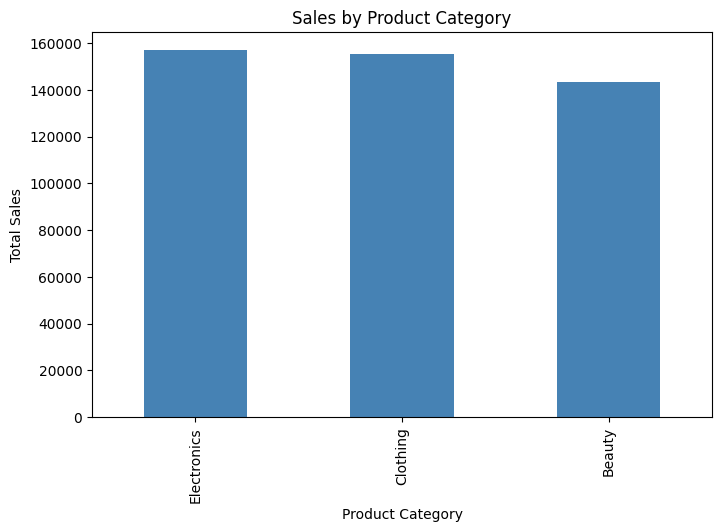

In [14]:
# 3.2 Sales by Category
# Visualization 1: Bar Chart
sales_by_category = (
    df_main.groupby('Product Category')['Total Amount']
      .sum()
      .sort_values(ascending=False)
)
sales_by_category
plt.figure(figsize=(8,5))
sales_by_category = df_main.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
sales_by_category.plot(
    kind='bar',
    color='steelblue'
)
plt.title("Sales by Product Category")
plt.ylabel("Total Sales")
plt.show()

3. Visualization (Minimum of 4 Required)

* Bar Chart
* Line Chart
* Pie Chart
* Box Plot

🧠 Questions to Answer adjusted based on dataset:
* What 'Product Category' generates the highest revenue?
* What 'Month' shows when people spend the most?
* Are there any unusual patterns or outliers?
* Which 'Age Group' spends the most?

In [15]:
# Business Question 1
sales_by_category.idxmax()

'Electronics'

In [16]:
# 3.3 Monthly Sales Trend
print(list(df_main.columns))
monthly_sales = (
    df_main.groupby('Month')['Total Amount']
      .sum()
)

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Year', 'Month', 'Age Group']


In [17]:
# For Proper Order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

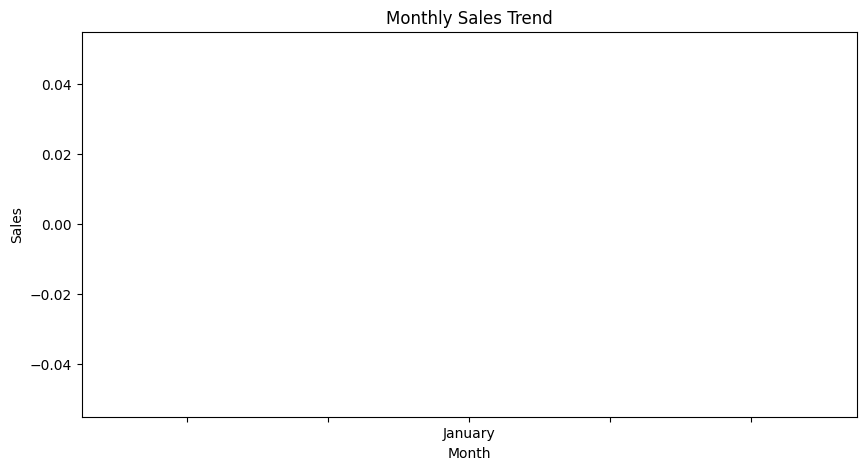

In [18]:
# Visualization 2: Line Chart
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

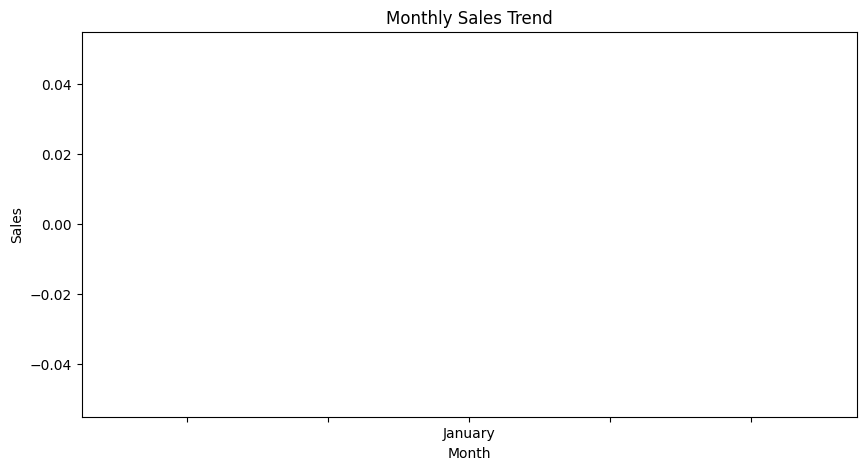

In [19]:
# Visualization 2: Line Chart
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

In [20]:
# Business Question 2
# Peak month:
monthly_sales.idxmax()

/tmp/ipykernel_5345/3246885756.py:3: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  monthly_sales.idxmax()


nan

In [21]:
df_main.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Year', 'Month', 'Age Group'],
      dtype='object')

# Team 6 Collaboration

## 📈 Step 4: Build Interactive Dashboard (Final Project)

📌 Task Create an interactive dashboard using: Dash (Plotly)

To help us in using Dash (Plotly) in Google Colab, here is a link that may prove as a guide:

https://colab.research.google.com/github/rapidsai/plotly-dash-rapids-census-demo/blob/main/plotly_demo/colab_plotly_rapids_app.ipynb

📊 Dashboard Must Include:

1. Filters

* Year dropdown OR category filter

2. Visualizations (minimum 4–5):

* Bar chart (Category vs Sales)
* Line chart (Time trend)
* Pie chart (Distribution)
* Box plot (Spread)
* Optional: Sunburst / Heatmap

🧠 Dashboard Features:

* Interactive filtering
* Dynamic charts
* Clean layout
* Clear titles and labels

💡 Bonus (Optional but recommended):

* KPI cards (Total Sales, Profit, Avg Value)
* YoY comparison
* Export dataset feature

In [22]:
# Karen, (Task: Setup, Dashboard Filters)

# Karen (Task: Dash App Setup, Dashboard Filters + Sample Graph - Histogram)

In [23]:
!pip install dash pandas plotly kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 67.6 MB/s eta 0:00:00


In [24]:
!pip install dash_bootstrap_components dash-html-components dash-core-components dash-daq dash-bootstrap-components

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.0/676.0 kB 13.6 MB/s eta 0:00:00


In [25]:
import os
import glob
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import kagglehub

# Data Preprocessing
df_main['Date'] = pd.to_datetime(df_main['Date'])
df_main['Year'] = df_main['Date'].dt.year
df_main.columns = df_main.columns.str.strip()

# Initialize the Dash
app = dash.Dash(__name__)


card_style = {
  'backgroundColor': '#D4F7FA',
  'padding': '20px',
  'borderRadius': '12px',
  'boxShadow': '0 4px 6px rgba(0,0,0,0.3)',
  'width': '50%',
  'textAlign': 'center',
  'border': '1px solid #e9ecef',
  'margin': '10px'
}

# App Layout
app.layout = html.Div([
    html.H1("Retail Sales Dashboard - Team 6", style={'textAlign': 'center', 'fontFamily': 'Arial', 'color': '#2c3e50'}),

    # Karen, Bonus (KPI CARDS)
    html.Div([
        html.Div([
            html.H3("Bonus (KPI CARDS) - Total Sales", style={'margin': '0', 'color': '#7f8c8d', 'fontSize': '16px', 'textTransform': 'uppercase'}),
            html.H1(id='kpi-total-sales', style={'margin': '10px 0 0 0', 'color': '#2c3e50', 'fontSize': '32px'})
        ], style=card_style),

        html.Div([
            html.H3("Bonus (KPI CARDS) - Total Profit", style={'margin': '0', 'color': '#7f8c8d', 'fontSize': '16px', 'textTransform': 'uppercase'}),
            html.H1(id='kpi-profit', style={'margin': '10px 0 0 0', 'color': '#27ae60', 'fontSize': '32px'})
        ], style=card_style),

        html.Div([
            html.H3("Bonus (KPI CARDS) - Avg Transaction Value", style={'margin': '0', 'color': '#7f8c8d', 'fontSize': '16px', 'textTransform': 'uppercase'}),
            html.H1(id='kpi-avg-value', style={'margin': '10px 0 0 0', 'color': '#2980b9', 'fontSize': '32px'})
        ], style=card_style),
    ], style={'display': 'flex', 'justifyContent': 'space-between', 'marginBottom': '30px', 'fontFamily': 'Arial'}),

    # Karen, Dashboard Filters
    html.Div([
        # Product Category Filter
        html.Div([
            html.Label("Select Product Category:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='category-dropdown',
                options=[{'label': cat, 'value': cat} for cat in df_main['Product Category'].unique()],
                value=df_main['Product Category'].unique().tolist(),  # Defaults to selecting all
                multi=True
            )
        ], style={'width': '48%', 'display': 'inline-block'}),

        # Year Filter
        html.Div([
            html.Label("Select Year:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='year-dropdown',
                options=[{'label': str(year), 'value': year} for year in sorted(df_main['Year'].unique())],
                value=sorted(df_main['Year'].unique()),  # Defaults to selecting all
                multi=True
            )
        ], style={'width': '48%', 'display': 'inline-block'})
    ], style={'display': 'flex', 'justifyContent': 'space-between', 'marginBottom': '30px', 'padding': '10px', 'backgroundColor': '#f8f9fa', 'borderRadius': '5px'}),

    # Graph Container
    html.Div([
        # histogram
        dcc.Graph(id='sales-histogram'),
        # sunburst
        dcc.Graph(id='sales-sunburst'),
        # bar
        dcc.Graph(id='sales-bar'),
        # line
        dcc.Graph(id='sales-line'),
        # pie
        dcc.Graph(id='sales-pie'),
        # box
        dcc.Graph(id='sales-box'),
    ])

], style={'padding': '20px', 'fontFamily': 'Arial'})

# Callback to link filters with the charts
@app.callback(
    [Output('sales-histogram', 'figure'),
     Output('sales-sunburst', 'figure'),
     Output('sales-bar', 'figure'),
     Output('sales-line', 'figure'),
     Output('sales-pie', 'figure'),
     Output('sales-box', 'figure'),
     Output('kpi-total-sales', 'children'),
     Output('kpi-profit', 'children'),
     Output('kpi-avg-value', 'children'),],
    [Input('category-dropdown', 'value'),
     Input('year-dropdown', 'value')]
)

# Update graph
def update_graph(selected_categories, selected_years):
    if not selected_categories or not selected_years:
        empty_fig = px.scatter(
            title="Please select at least one Product Category and Year."
        )
        return empty_fig, empty_fig

    # Filter the dataset dynamically
    filtered_df = df_main[
        (df_main['Product Category'].isin(selected_categories)) &
        (df_main['Year'].isin(selected_years))
    ]

    # Karen, Sample Graph (Histogram)
    hist_fig = px.histogram(
        filtered_df,
        x='Total Amount',
        nbins=25,
        title='(Karen) Histogram - Distribution of Sales (By Count and Transaction Value per Product Category)',
        labels={'Total Amount': 'Transaction Value ($)', 'count': 'Transaction Count'},
        color='Product Category',
        barmode='overlay'
    )

    hist_fig.update_layout(
        bargap=0.08,
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='#e9ecef'),
        yaxis=dict(showgrid=True, gridcolor='#e9ecef'),
        title_font=dict(size=18, family='Arial')
    )

    # Vishnu, Sunburst
    sunburst_data = (
        filtered_df
        .groupby(['Product Category', 'Gender', 'Age Group'])['Total Amount']
        .sum()
        .reset_index()
    )
    sunburst_fig = px.sunburst(
        sunburst_data,
        path=['Product Category', 'Gender', 'Age Group'],
        values='Total Amount',
        title='(Vishnu, Sunburst) Retail Sales Distribution by Category → Gender → Age Group'
    )

    # Tintu, Bar
    bar_data = (
      filtered_df.groupby('Product Category')['Total Amount']
      .sum()
      .reset_index()
      .sort_values('Total Amount', ascending=False)
    )

    bar_fig = px.bar(
      bar_data,
      x='Product Category',
      y='Total Amount',
      title='(Tintu, Bar) Total Sales by Product Category',
      text_auto=True,
      color='Product Category',
      color_discrete_sequence=px.colors.qualitative.Set2
    )
    bar_fig.update_layout(
      xaxis_title='Product Category',
      yaxis_title='Total Sales ($)',
      showlegend=False,
      width=900,
      height=700,
      plot_bgcolor='white',
      paper_bgcolor='white'
    )

    # Linda, Line
    df_main['Year_Month'] = pd.to_datetime(df_main['Date']).dt.to_period('M').astype(str)
    monthly_sales = df_main.groupby('Year_Month')['Total Amount'].sum().reset_index()
    line_fig = px.line(monthly_sales, x='Year_Month', y='Total Amount', markers=True,
              title='(Linda, Line) Monthly Sales Trend')
    line_fig.update_layout(xaxis_title='Month', yaxis_title='Total Amount')

    # Glen, Pie
    category_units = df_main.groupby('Product Category')['Quantity'].sum().reset_index()
    pie_fig = px.pie(category_units,
             values='Quantity',
             names='Product Category',
             title='(Glen, Pie) Total Quantity Purchased Per Product Category')
    pie_fig.update_traces(textposition='inside', textinfo='percent+label')

    # Mounika, Box Plot
    box_fig = px.box (
      df_main,
      x = 'Age Group',
      y = 'Total Amount',
      title = '(Mounika, Box Plot) Distribution of Total Purchase Amount by Age Group',
      category_orders={
          'Age Group': ['00s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90+']
      }
    )

    box_fig.update_layout(
      xaxis_title = 'Age Group',
      yaxis_title = 'Total Purchase Amount ($)',
      showlegend = False,
      width=900,
      height=700
    )

    # Karen, Bonus (KPI CARDS)
    all_possible_categories = df_main['Product Category'].unique().tolist()
    if len(selected_categories) == len(all_possible_categories):
        category_label = "All Categories"
    elif len(selected_categories) == 1:
        category_label = selected_categories[0]
    elif len(selected_categories) <= 3:
        category_label = ", ".join(selected_categories)  # e.g., "Electronics, Clothing"
    else:
        category_label = f"{len(selected_categories)} Categories Selected"

    total_sales = filtered_df['Quantity'].sum() if not filtered_df.empty else 0
    total_profit = filtered_df['Total Amount'].sum() if not filtered_df.empty else 0
    avg_value = filtered_df['Total Amount'].mean() if not filtered_df.empty else 0
    sales_str = f"${total_sales:,.2f}"
    profit_str = f"${total_profit:,.2f} ({category_label})"
    avg_str = f"${avg_value:,.2f}"

    return hist_fig, sunburst_fig, bar_fig, line_fig, pie_fig, box_fig, sales_str, profit_str, avg_str


# Karen (Task: Render Dashboard Website via Plotly Dash)

In [26]:
# Install pyngrok if not already installed
!pip install pyngrok -q


In [ ]:
import os
from pyngrok import ngrok, conf
from google.colab import userdata

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get ngrok authentication token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Check if the token is available
if NGROK_AUTH_TOKEN:
    # Set ngrok authtoken
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("ngrok authtoken set.")

    # Open a tunnel to port 8050, where the Dash app is running
    # The Dash app is running on port 8050, as specified in `app.run(jupyter_mode="inline", port=8050)`
    public_url = ngrok.connect(8050)

    print(f"Dash app is publicly available at: {public_url}")
else:
    print("NGROK_AUTH_TOKEN not found. Please add it to Colab secrets as instructed.")

if __name__ == '__main__':
    # Force Dash to listen on all interfaces so ngrok can find it
    app.run(host='0.0.0.0', port=8050)

ngrok authtoken set.
Dash app is publicly available at: NgrokTunnel: "https://balsamic-numbness-vanish.ngrok-free.dev" -> "http://localhost:8050"
Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8050
 * Running on http://172.28.0.12:8050
INFO:werkzeug:Press CTRL+C to quit


# Final Submission Requirements

📦 Final Submission Requirements

You must submit:
1. Python notebook or script
* Data cleaning + EDA + dashboard code

2. Dataset used
* Original dataset file or link

3. Short report (1–2 pages) Include:
* Dataset chosen
* Key insights
* Challenges faced
* What you learned

# Karen, Histogram (Dashboard Filters and Sample Graph Without Plotly Dash)

In [ ]:
import pandas as pd
import plotly.express as px

# --- Data Preprocessing ---
df_main['Date'] = pd.to_datetime(df_main['Date'])
df_main['Year'] = df_main['Date'].dt.year
df_main.columns = df_main.columns.str.strip()

# --- Filter Configuration ---
selected_categories = df_main['Product Category'].unique().tolist()
selected_years = sorted(df_main['Year'].unique())

# Filter the dataset
filtered_df = df_main[
    (df_main['Product Category'].isin(selected_categories)) &
    (df_main['Year'].isin(selected_years))
]

# --- Base Histogram Setup ---
fig_hist = px.histogram(
    filtered_df,
    x='Total Amount',
    color='Product Category',
    facet_col='Year',
    nbins=25,
    title='Distribution of Sales (Total Amount) by Category & Year',
    labels={'Total Amount': 'Transaction Value ($)', 'count': 'Transaction Count'},
    barmode='overlay'
)

# --- Defining the Update Menu (Dropdown Buttons) ---

# Product Category Dropdown Buttons
category_buttons = []
# "All" button
category_buttons.append(dict(
    method="update",
    label="All Categories",
    args=[{"visible": [True] * len(fig_hist.data)}]
))

# Individual category toggles
for cat in selected_categories:
    visibility = [trace.name == cat for trace in fig_hist.data]
    category_buttons.append(dict(
        method="update",
        label=cat,
        args=[{"visible": visibility}]
    ))

# Year Dropdown Buttons
year_buttons = []
year_buttons.append(dict(
    method="update",
    label="All Years",
    args=[{"xaxis.visible": True}]
))

# Configure the layout to anchor the dropdown menus
fig_hist.update_layout(
    updatemenus=[
        dict(
            buttons=category_buttons,
            direction="down",
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        ),
    ],
    bargap=0.08,
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(size=18, family='Arial')
)

# --- Render the Figure ---
fig_hist.show()

# Vishnu, Sunburst Chart

In [ ]:
# --- Sunburst Chart (Vishnu) ---
sunburst_data = (
    filtered_df
    .groupby(['Product Category', 'Gender', 'Age Group'])['Total Amount']
    .sum()
    .reset_index()
)

fig_sunburst = px.sunburst(
    sunburst_data,
    path=['Product Category', 'Gender', 'Age Group'],
    values='Total Amount',
    title='Retail Sales Distribution by Category → Gender → Age Group'
)
fig_sunburst.show()

# Tintu, Bar Chart

In [ ]:
# 1 Tintu working on Bar Chart (Category vs Sales)
import plotly.express as px

# Aggregate sales by Product Category
category_sales = (
    df_main.groupby('Product Category')['Total Amount']
    .sum()
    .reset_index()
    .sort_values('Total Amount', ascending=False)
)

# Create Bar Chart
fig = px.bar(
    category_sales,
    x='Product Category',
    y='Total Amount',
    title='Total Sales by Product Category',
    text_auto=True,
    color='Product Category',
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Update layout for clean look
fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Total Sales ($)',
    showlegend=False,
    width=900,
    height=700,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

# Linda, Line Chart

In [ ]:
# 2 Linda's Code

import pandas as pd
import plotly.express as px
df_main['Year_Month'] = pd.to_datetime(df_main['Date']).dt.to_period('M').astype(str)
monthly_sales = df_main.groupby('Year_Month')['Total Amount'].sum().reset_index()
fig = px.line(monthly_sales, x='Year_Month', y='Total Amount', markers=True,
              title='Monthly Sales Trend')
fig.update_layout(xaxis_title='Month', yaxis_title='Total Amount')
fig.show()

# Glen, Pie Chart

In [ ]:
# Glen - pie chart
import pandas as pd
import plotly.express as px

# Aggregate the total quantity purchased per product category
category_units = df_main.groupby('Product Category')['Quantity'].sum().reset_index()

# Creating the pie chart: Number of units purchased, per category:
fig = px.pie(category_units,
             values='Quantity',
             names='Product Category',
             title='Total Quantity Purchased Per Product Category')

# Added labels and formatting to improve readability
fig.update_traces(textposition='inside', textinfo='percent+label')
# Display the chart
fig.show()


# Mounika, Box Plot

In [ ]:
#4 Mounika working on Box Plot
import plotly.express as px

fig = px.box (
df_main,
x = 'Age Group',
y = 'Total Amount',
title = 'Distribution of Total Purchase Amount by Age Group',
category_orders={
    'Age Group': ['00s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90+']
}
)

fig.update_layout(
xaxis_title = 'Age Group',
yaxis_title = 'Total Purchase Amount ($)',
showlegend = False,
width=900,
height=700
)

fig.show()